# **BỘ DỮ LIỆU BIẾN NGOẠI SINH **

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Đọc file

In [2]:
exo = pd.read_csv("/content/drive/MyDrive/DACS_2/data/data_ngoai_sinh.csv")

exo.head()
exo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6571 entries, 0 to 6570
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Date            6571 non-null   object
 1   NgayTrongTuan   6571 non-null   int64 
 2   ThangTrongNam   6571 non-null   int64 
 3   QuyTrongNam     6571 non-null   int64 
 4   Nam             6571 non-null   int64 
 5   NgayTrongThang  6571 non-null   int64 
 6   TuanTrongNam    6571 non-null   int64 
 7   IsWeekend       6571 non-null   int64 
 8   IsMonthStart    6571 non-null   int64 
 9   IsMonthEnd      6571 non-null   int64 
 10  NgayLeSG        6571 non-null   int64 
 11  NgayLeVN        6571 non-null   int64 
 12  NgayLe          6571 non-null   int64 
 13  SuKienDacBiet   6571 non-null   int64 
 14  GanNgayLe       6571 non-null   int64 
dtypes: int64(14), object(1)
memory usage: 770.2+ KB


Chuẩn hóa cột Date

In [3]:
exo["Date"] = pd.to_datetime(exo["Date"], errors="coerce")

# Bỏ dòng ngày không hợp lệ nếu có
exo = exo.dropna(subset=["Date"]).copy()

# Sắp xếp theo thời gian
exo = exo.sort_values("Date").reset_index(drop=True)

print("Ngày bắt đầu:", exo["Date"].min())
print("Ngày kết thúc:", exo["Date"].max())
exo.head()

Ngày bắt đầu: 2008-01-05 00:00:00
Ngày kết thúc: 2025-12-31 00:00:00


,Date,NgayTrongTuan,ThangTrongNam,QuyTrongNam,Nam,NgayTrongThang,TuanTrongNam,IsWeekend,IsMonthStart,IsMonthEnd,NgayLeSG,NgayLeVN,NgayLe,SuKienDacBiet,GanNgayLe
0,2008-01-05,6,1,1,2008,5,1,1,0,0,0,0,0,0,0
1,2008-01-06,7,1,1,2008,6,1,1,0,0,0,0,0,0,0
2,2008-01-07,1,1,1,2008,7,2,0,0,0,0,0,0,0,0
3,2008-01-08,2,1,1,2008,8,2,0,0,0,0,0,0,0,0
4,2008-01-09,3,1,1,2008,9,2,0,0,0,0,0,0,0,0


Kiểm tra missing và ngày trùng

In [4]:
missing_table = pd.DataFrame({
    "missing_count": exo.isna().sum(),
    "missing_percent": exo.isna().mean() * 100
}).sort_values("missing_count", ascending=False)

display(missing_table)

,missing_count,missing_percent
Date,0,0.0
NgayTrongTuan,0,0.0
ThangTrongNam,0,0.0
QuyTrongNam,0,0.0
Nam,0,0.0
NgayTrongThang,0,0.0
TuanTrongNam,0,0.0
IsWeekend,0,0.0
IsMonthStart,0,0.0
IsMonthEnd,0,0.0


Kiểm tra các biến nhị phân

In [5]:
binary_cols = [
    "IsWeekend",
    "IsMonthStart",
    "IsMonthEnd",
    "NgayLeSG",
    "NgayLeVN",
    "NgayLe",
    "SuKienDacBiet",
    "GanNgayLe"
]

binary_cols = [col for col in binary_cols if col in exo.columns]

for col in binary_cols:
    print(col, ":", sorted(exo[col].dropna().unique()))

IsWeekend : [np.int64(0), np.int64(1)]
IsMonthStart : [np.int64(0), np.int64(1)]
IsMonthEnd : [np.int64(0), np.int64(1)]
NgayLeSG : [np.int64(0), np.int64(1)]
NgayLeVN : [np.int64(0), np.int64(1)]
NgayLe : [np.int64(0), np.int64(1)]
SuKienDacBiet : [np.int64(0), np.int64(1)]
GanNgayLe : [np.int64(0), np.int64(1)]


Kiểm tra các biến nhị phân

In [6]:

print("Số ngày cuối tuần:", exo["IsWeekend"].sum())

Số ngày cuối tuần: 1878


Trực quan hoá

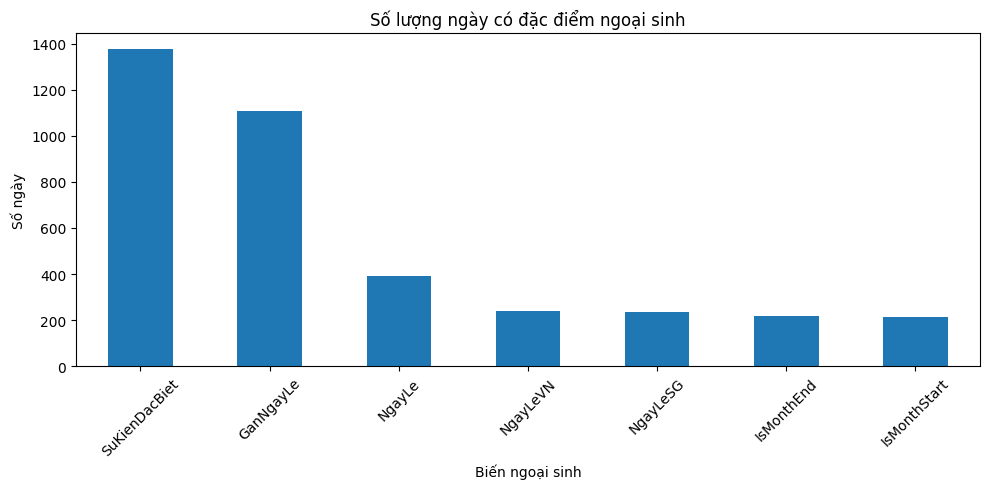

,0
SuKienDacBiet,1376
GanNgayLe,1109
NgayLe,390
NgayLeVN,241
NgayLeSG,234
IsMonthEnd,216
IsMonthStart,215


In [7]:
event_cols = [
    "NgayLeSG",
    "NgayLeVN",
    "NgayLe",
    "SuKienDacBiet",
    "GanNgayLe",
    "IsMonthStart",
    "IsMonthEnd"
]

event_cols = [col for col in event_cols if col in exo.columns]

event_counts = exo[event_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
event_counts.plot(kind="bar")

plt.title("Số lượng ngày có đặc điểm ngoại sinh")
plt.xlabel("Biến ngoại sinh")
plt.ylabel("Số ngày")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(event_counts)

Trực quan hoá biểu đồ ngày lễ

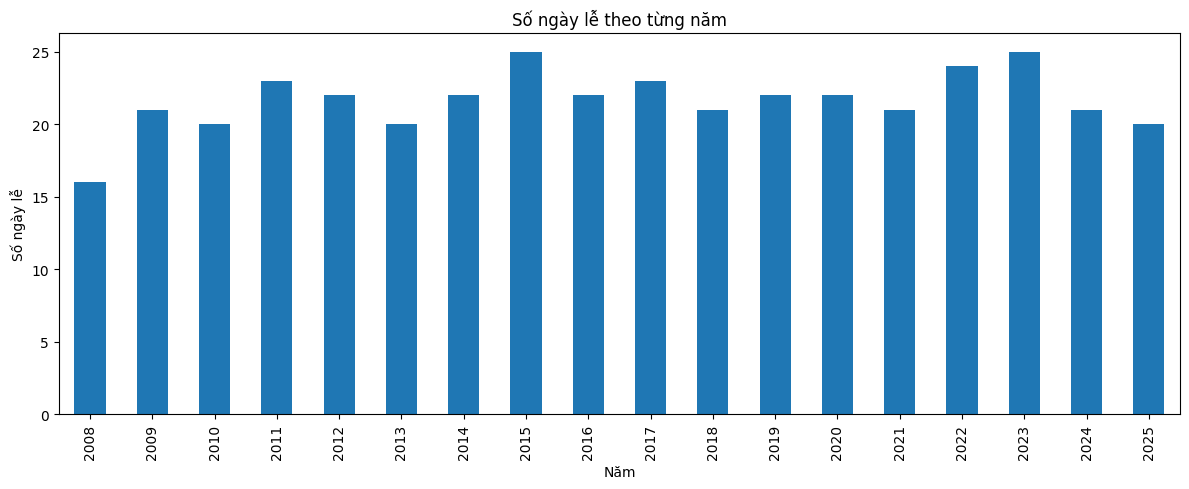

In [8]:
holiday_by_year = exo.groupby("Nam")["NgayLe"].sum()

plt.figure(figsize=(12, 5))
holiday_by_year.plot(kind="bar")

plt.title("Số ngày lễ theo từng năm")
plt.xlabel("Năm")
plt.ylabel("Số ngày lễ")
plt.tight_layout()
plt.show()

Heatmap tương quan biến ngoại sinh

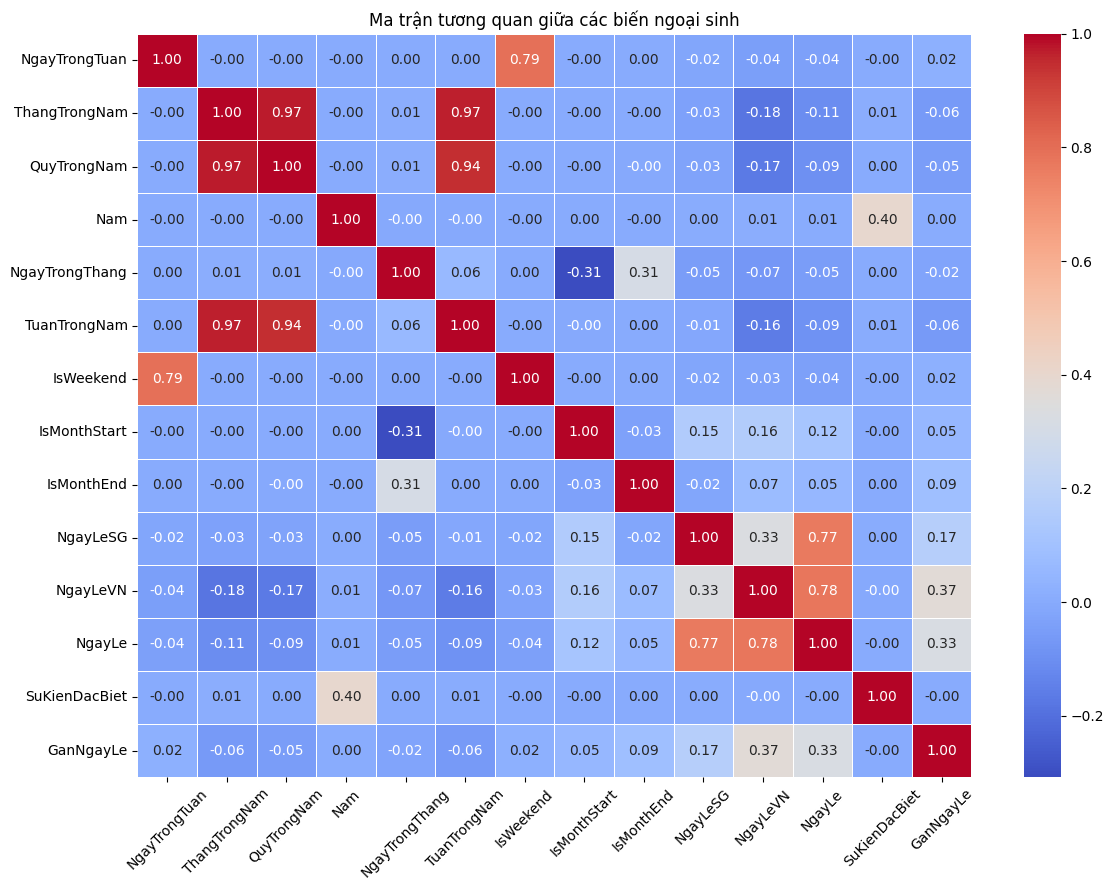

In [9]:
corr_cols = [
    "NgayTrongTuan",
    "ThangTrongNam",
    "QuyTrongNam",
    "Nam",
    "NgayTrongThang",
    "TuanTrongNam",
    "IsWeekend",
    "IsMonthStart",
    "IsMonthEnd",
    "NgayLeSG",
    "NgayLeVN",
    "NgayLe",
    "SuKienDacBiet",
    "GanNgayLe"
]

corr_cols = [col for col in corr_cols if col in exo.columns]

corr_exo = exo[corr_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr_exo, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

plt.title("Ma trận tương quan giữa các biến ngoại sinh")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Lưu File

In [10]:
exo_processed_full = exo.copy()

exo_processed_full.to_csv(
    "exo_processed_full.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Đã lưu file: exo_processed_full.csv")
print("Kích thước:", exo_processed_full.shape)

Đã lưu file: exo_processed_full.csv
Kích thước: (6571, 15)


Bản chọn lọc để merge với price và GPR.

In [11]:
exo_selected_cols = [
    "Date",
    "IsMonthStart",
    "IsMonthEnd",
    "NgayLeSG",
    "NgayLeVN",
    "NgayLe",
    "SuKienDacBiet",
    "GanNgayLe"
]

exo_selected_cols = [col for col in exo_selected_cols if col in exo.columns]

exo_selected_features = exo[exo_selected_cols].copy()

exo_selected_features.to_csv(
    "exo_selected_features.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Đã lưu file: exo_selected_features.csv")
print("Kích thước:", exo_selected_features.shape)
display(exo_selected_features.head())

Đã lưu file: exo_selected_features.csv
Kích thước: (6571, 8)


,Date,IsMonthStart,IsMonthEnd,NgayLeSG,NgayLeVN,NgayLe,SuKienDacBiet,GanNgayLe
0,2008-01-05,0,0,0,0,0,0,0
1,2008-01-06,0,0,0,0,0,0,0
2,2008-01-07,0,0,0,0,0,0,0
3,2008-01-08,0,0,0,0,0,0,0
4,2008-01-09,0,0,0,0,0,0,0
